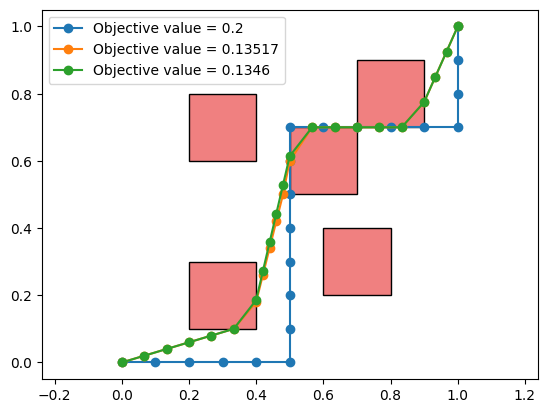

In [12]:
# This was originally the example of obstacle avoidance from lecture.
# The repository is https://github.com/TobiaMarcucci/olrc-code/blob/main/examples/chapter4/obstacle_avoidance_dcf.ipynb
# I just made some tweaks.

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Some square obstacles. The radius is distance from center to one of its 4 sides
radius = .1
centers = np.array([
    [.7, .3],
    [.8, .8],
    [.3, .2],
    [.3, .7],
    [.6, .6],
])

# # This is just making a initial guess for the best trajectory. Remember our variables are x1, ..., xK
# initial_points = np.vstack([
#     np.linspace([0, 0], [.5, 0], 6),    # [0, 0], [0.1, 0], [0.2, 0], [0.3, 0], [0.4, 0], [0.5, 0] , [0.6, 0]
#     np.linspace([.5, .1], [.5, .7], 7), # [0.5, 0.1], [0.5, 0.2], [0.5, 0.3], [0.5, 0.4], [0.5, 0.5], [0.5, 0.6], [0.5, 0.7], 
#     np.linspace([.6, .7], [1, .7], 5),  # [0.6, 0.7], [0.7, 0.7], [0.8, 0.7], [0.9, 0.7], [1, 0.7]
#     np.linspace([1, .8], [1, 1], 3),    # [1, 0.8], [1, 0.9], [1, 1]
# ])

# This is just making a initial guess for the best trajectory. Remember our variables are x1, ..., xK
initial_points = np.vstack([
    np.linspace([0, 0], [.5, 0], 6),    # [0, 0], [0.1, 0], [0.2, 0], [0.3, 0], [0.4, 0], [0.5, 0] , [0.6, 0]
    np.linspace([.5, .1], [.5, .7], 7), # [0.5, 0.1], [0.5, 0.2], [0.5, 0.3], [0.5, 0.4], [0.5, 0.5], [0.5, 0.6], [0.5, 0.7], 
    np.linspace([.6, .7], [1, .7], 5),  # [0.6, 0.7], [0.7, 0.7], [0.8, 0.7], [0.9, 0.7], [1, 0.7]
    np.linspace([1, .8], [1, 1], 3),    # [1, 0.8], [1, 0.9], [1, 1]
])

def objective_function(points):
    return cp.sum_squares(points[1:] - points[:-1]) #Sum of squared distances

# Take the 2nd term in each constraint and do a 2nd order approximation of it. This is for the relaxation of nonconvex constraints
def linearized_constraint(p, p_new, c):
    diff = p - c
    dist = np.linalg.norm(diff, ord = np.inf) # BIGGEST CHANGE: Set the norm to infinity norm
    offset = radius - dist

# Next 3 lines show general formula for gradient of p norm
    # Because the infinity norm is not differentiable and has a piecewise graident, 
    # I figure out which absolute value component of diff is largest
    if np.abs(diff[0]) > np.abs(diff[1]):
        gradient = np.array([np.sign(diff[0]), 0.0])
    else:   # Implicitly this handles the = case, so this is computing a subgradient
        gradient = np.array([0.0, np.sign(diff[1])])

    return offset - gradient @ (p_new - p) <= 0


tol = 1e-3  # 1/1000 (for convergence)
solutions = [initial_points] # stores trajectories at all iterations for plotting
values = [objective_function(initial_points).value] # stores objective values at all iterations for showing evolution
while True:
    points = solutions[-1] # previous trajectory
    new_points = cp.Variable(points.shape)  #K different positions
    constraints = [
        new_points[0] == points[0], # initial point is fixed
        new_points[-1] == points[-1] # kth final point is fixed
        ]
    for p, p_new in zip(points, new_points):
        for c in centers:
            # linearized obstacle avoidance
            constraints.append(linearized_constraint(p, p_new, c))
    obj = objective_function(new_points)
    prob = cp.Problem(cp.Minimize(obj), constraints)
    prob.solve()

    # Convergence check.
    if (values[-1] - prob.value) / prob.value < tol:
        break
    solutions.append(new_points.value)
    values.append(prob.value)
# Plot result.
plt.figure()
plt.axis('equal')
for c in centers:   #To draw the squares, we use the bottom left corner and side length of each square
    bottom_left = [c[0] - radius, c[1] - radius]
    side_length = 2 * radius
    patch = Rectangle(bottom_left, side_length, side_length, facecolor='lightcoral', edgecolor='black')
    plt.gca().add_patch(patch)


for points, value in zip(solutions, values):
    rounded_value = np.round(value, 5)
    plt.plot(*points.T, marker='o', label=f"Objective value = {rounded_value}")
plt.legend()
plt.show()